# HW10-11 — computer vision in PyTorch

В этом ноутбуке:

- часть A: классификация на `STL10` с CNN, аугментациями и transfer learning на `ResNet18` с pretrained weights (`ResNet18_Weights.DEFAULT`), включая режимы `head-only` и `partial fine-tuning`;
- часть B: сегментация на `OxfordIIITPet` с pretrained `DeepLabV3-ResNet50`;
- все прогоны сохраняются в `artifacts/runs.csv`.

## 1. Импорты, seed и устройство

In [3]:
import os
import json
import math
import copy
import random
import ssl
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import certifi

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

print("torch:", torch.__version__)
print("torchvision:", __import__("torchvision").__version__)

# Fix for certificate verification issues when downloading torchvision weights/datasets.
# This is especially useful on macOS / local Python installs where the system CA bundle
# may not be picked up automatically by urllib.
os.environ.setdefault("SSL_CERT_FILE", certifi.where())
os.environ.setdefault("REQUESTS_CA_BUNDLE", certifi.where())

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

HW_DIR = Path(".")
ART_DIR = HW_DIR / "artifacts"
FIG_DIR = ART_DIR / "figures"
for p in [HW_DIR, ART_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Общие параметры для быстрых и воспроизводимых прогонов.
FAST_MODE = True
CLASS_BATCH_SIZE = 64
RESNET_BATCH_SIZE = 32
SEG_BATCH_SIZE = 1

CLASS_EPOCHS = 5
RESNET_HEAD_EPOCHS = 3
RESNET_FT_EPOCHS = 3

MAX_TRAIN_SAMPLES = 2500
MAX_VAL_SAMPLES = 600
MAX_TEST_SAMPLES = 800
MAX_SEG_SAMPLES = 80

print("FAST_MODE:", FAST_MODE)

torch: 2.10.0
torchvision: 0.25.0
device: cpu
FAST_MODE: True


## 2. Общие утилиты

Функции ниже используются и в части A, и в части B: разбиение, оценка, визуализация и сохранение артефактов.

In [2]:
def split_indices(n: int, val_ratio: float = 0.2, seed: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    rng = np.random.RandomState(seed)
    indices = np.arange(n)
    rng.shuffle(indices)
    n_val = int(n * val_ratio)
    val_idx = indices[:n_val]
    train_idx = indices[n_val:]
    return train_idx, val_idx

def take_limited(indices: np.ndarray, max_n: int, seed: int = 42) -> np.ndarray:
    if max_n is None or len(indices) <= max_n:
        return indices
    rng = np.random.RandomState(seed)
    return np.sort(rng.choice(indices, size=max_n, replace=False))

@torch.no_grad()
def compute_mean_std(dataset, indices: np.ndarray, batch_size: int = 128) -> Tuple[Tuple[float, float, float], Tuple[float, float, float]]:
    loader = DataLoader(Subset(dataset, indices), batch_size=batch_size, shuffle=False, num_workers=0)
    channel_sum = torch.zeros(3)
    channel_sum_sq = torch.zeros(3)
    total_pixels = 0
    for x, _ in loader:
        x = x.float()
        b, c, h, w = x.shape
        channel_sum += x.sum(dim=(0, 2, 3))
        channel_sum_sq += (x ** 2).sum(dim=(0, 2, 3))
        total_pixels += b * h * w
    mean = channel_sum / total_pixels
    std = torch.sqrt(channel_sum_sq / total_pixels - mean ** 2).clamp_min(1e-8)
    return tuple(mean.tolist()), tuple(std.tolist())

def show_image_grid(images, titles=None, ncols=4, figsize=(12, 8), cmap=None):
    n = len(images)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(nrows, ncols)
    for i in range(nrows * ncols):
        ax = axes.flat[i]
        ax.axis("off")
        if i < n:
            ax.imshow(images[i], cmap=cmap)
            if titles is not None:
                ax.set_title(titles[i], fontsize=9)
    plt.tight_layout()
    return fig, axes

def denormalize_tensor(x: torch.Tensor, mean, std):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    x = x.cpu() * std + mean
    return x.clamp(0, 1)

def tensor_to_pil(x: torch.Tensor, mean=None, std=None):
    if mean is not None and std is not None:
        x = denormalize_tensor(x, mean, std)
    x = (x.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    return Image.fromarray(x)

def save_figure(path: Path):
    plt.savefig(path, bbox_inches="tight", dpi=160)
    plt.close()

def to_device(batch, device=DEVICE):
    x, y = batch
    return x.to(device), y.to(device)

## 3. Часть A — классификация на STL10

Выбран `STL10`: изображения уже достаточно крупные, поэтому удобно показать и обычную CNN, и pretrained `ResNet18`.

In [3]:
# 3.1. Загружаем raw STL10 (без нормализации) и считаем статистики по train split
stl10_raw = datasets.STL10(
    root=str(ROOT / "data"),
    split="train",
    download=True,
    transform=transforms.ToTensor(),
)

train_idx_all, val_idx_all = split_indices(len(stl10_raw), val_ratio=0.2, seed=SEED)

if FAST_MODE:
    train_idx = take_limited(train_idx_all, MAX_TRAIN_SAMPLES, seed=SEED)
    val_idx = take_limited(val_idx_all, MAX_VAL_SAMPLES, seed=SEED)
else:
    train_idx, val_idx = train_idx_all, val_idx_all

test_raw = datasets.STL10(
    root=str(ROOT / "data"),
    split="test",
    download=True,
    transform=transforms.ToTensor(),
)
test_idx = np.arange(len(test_raw))
if FAST_MODE:
    test_idx = take_limited(test_idx, MAX_TEST_SAMPLES, seed=SEED)

stl_mean, stl_std = compute_mean_std(stl10_raw, train_idx)
stl_mean, stl_std

100.0%


((0.4484017789363861, 0.44134560227394104, 0.4075521230697632),
 (0.26044806838035583, 0.25732001662254333, 0.2721908390522003))

In [4]:
# 3.2. Transforms для CNN и для ResNet18
cnn_base_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(stl_mean, stl_std),
])

cnn_aug_tf = transforms.Compose([
    transforms.RandomCrop(96, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(stl_mean, stl_std),
])

resnet_weights = ResNet18_Weights.DEFAULT
resnet_eval_tf = resnet_weights.transforms()

print("ResNet preprocess:", resnet_eval_tf)

ResNet preprocess: ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [5]:
# 3.3. Датасеты и DataLoader'ы

def build_stl10_loaders(train_tf, eval_tf, batch_size: int, seed: int = 42):
    train_ds = datasets.STL10(
        root=str(ROOT / "data"),
        split="train",
        download=True,
        transform=train_tf,
    )
    val_ds = datasets.STL10(
        root=str(ROOT / "data"),
        split="train",
        download=True,
        transform=eval_tf,
    )
    test_ds = datasets.STL10(
        root=str(ROOT / "data"),
        split="test",
        download=True,
        transform=eval_tf,
    )

    train_subset = Subset(train_ds, train_idx)
    val_subset = Subset(val_ds, val_idx)
    test_subset = Subset(test_ds, test_idx)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())
    test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())
    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader

cnn_train_ds, cnn_val_ds, cnn_test_ds, cnn_train_loader, cnn_val_loader, cnn_test_loader = build_stl10_loaders(
    cnn_base_tf, cnn_base_tf, CLASS_BATCH_SIZE, seed=SEED
)

cnn_aug_train_ds, cnn_aug_val_ds, cnn_aug_test_ds, cnn_aug_train_loader, cnn_aug_val_loader, cnn_aug_test_loader = build_stl10_loaders(
    cnn_aug_tf, cnn_base_tf, CLASS_BATCH_SIZE, seed=SEED
)

resnet_train_ds, resnet_val_ds, resnet_test_ds, resnet_train_loader, resnet_val_loader, resnet_test_loader = build_stl10_loaders(
    resnet_eval_tf, resnet_eval_tf, RESNET_BATCH_SIZE, seed=SEED
)

print("train batch size (CNN):", next(iter(cnn_train_loader))[0].shape)
print("val batch size (CNN):", next(iter(cnn_val_loader))[0].shape)
print("train batch size (ResNet):", next(iter(resnet_train_loader))[0].shape)

train batch size (CNN): torch.Size([64, 3, 96, 96])
val batch size (CNN): torch.Size([64, 3, 96, 96])
train batch size (ResNet): torch.Size([32, 3, 224, 224])


x_batch.shape = (64, 3, 96, 96)
y_batch.shape = (64,)


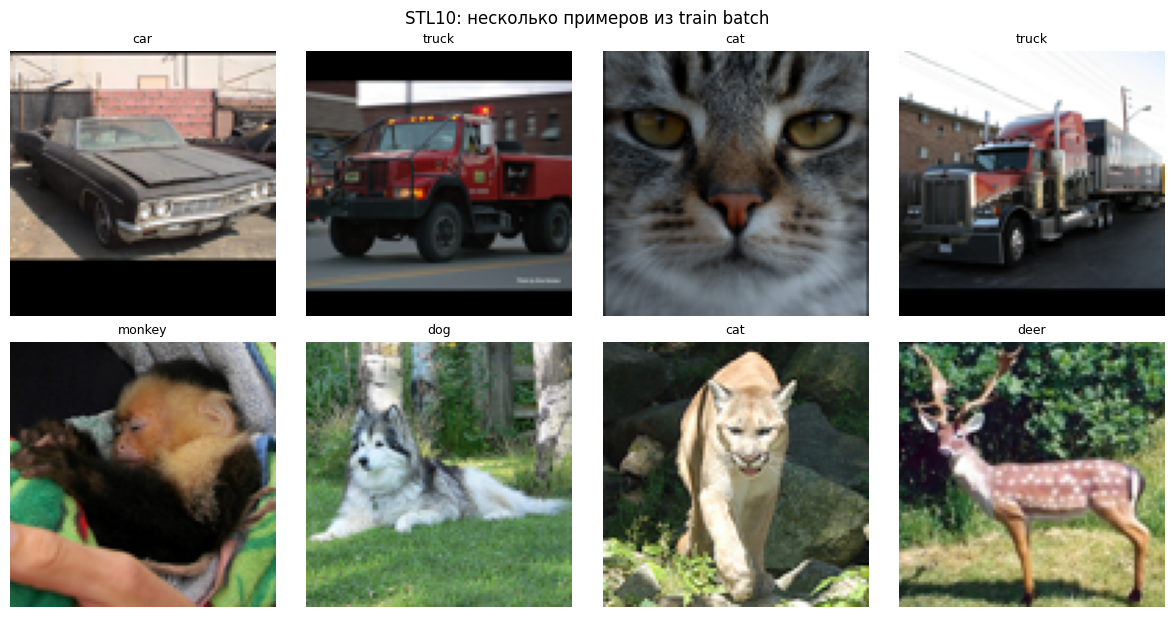

In [6]:
# 3.4. Sanity-check: размеры батча и несколько примеров
x_batch, y_batch = next(iter(cnn_train_loader))
print("x_batch.shape =", tuple(x_batch.shape))
print("y_batch.shape =", tuple(y_batch.shape))

label_names = stl10_raw.classes
preview_x = []
preview_titles = []
for i in range(min(8, x_batch.size(0))):
    preview_x.append(tensor_to_pil(x_batch[i], stl_mean, stl_std))
    preview_titles.append(label_names[int(y_batch[i])])

fig, _ = show_image_grid(preview_x, preview_titles, ncols=4, figsize=(12, 6))
plt.suptitle("STL10: несколько примеров из train batch", y=1.02)
plt.show()

In [7]:
# 3.5. Визуализация аугментаций

def preview_augmentations(dataset_plain, dataset_aug, indices, mean, std, n_examples: int = 4):
    n_examples = min(n_examples, len(indices))
    fig, axes = plt.subplots(n_examples, 3, figsize=(11, 3.2 * n_examples))
    if n_examples == 1:
        axes = np.expand_dims(axes, axis=0)

    for row in range(n_examples):
        idx = int(indices[row])
        x_plain, y_plain = dataset_plain[idx]
        x_aug1, y_aug1 = dataset_aug[idx]
        x_aug2, y_aug2 = dataset_aug[idx]

        axes[row, 0].imshow(tensor_to_pil(x_plain, mean, std))
        axes[row, 0].set_title(f"original / {label_names[y_plain]}")
        axes[row, 1].imshow(tensor_to_pil(x_aug1, mean, std))
        axes[row, 1].set_title("augmented view 1")
        axes[row, 2].imshow(tensor_to_pil(x_aug2, mean, std))
        axes[row, 2].set_title("augmented view 2")
        for col in range(3):
            axes[row, col].axis("off")
    plt.tight_layout()
    return fig

_ = preview_augmentations(cnn_val_ds, cnn_aug_train_ds, val_idx[:4], stl_mean, stl_std, n_examples=4)
save_figure(FIG_DIR / "augmentations_preview.png")
print("saved:", FIG_DIR / "augmentations_preview.png")

saved: homeworks/HW10-11/artifacts/figures/augmentations_preview.png


### 3.6. Модель CNN

Одна и та же архитектура используется в `C1` и `C2`; отличается только аугментация данных.

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def accuracy_from_logits(logits, y):
    return (logits.argmax(dim=1) == y).float().mean().item()

@torch.no_grad()
def evaluate(model, loader, criterion, device=DEVICE):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_seen = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_seen += bs
    return total_loss / total_seen, total_correct / total_seen

def train_one_epoch(model, loader, optimizer, criterion, device=DEVICE):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_seen = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_seen += bs
    return total_loss / total_seen, total_correct / total_seen

def fit_classifier(model, train_loader, val_loader, optimizer, criterion, epochs: int, device=DEVICE):
    history = []
    best_state = None
    best_val_acc = -1.0
    best_epoch = -1

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device=device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device=device)
        history.append({
            "epoch": epoch,
            "train_loss": tr_loss,
            "train_acc": tr_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
        print(f"epoch {epoch:02d} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    history_df = pd.DataFrame(history)
    return history_df, best_state, best_val_acc, best_epoch

### 3.7. Transfer learning на `ResNet18`

В этой части используется `ResNet18_Weights.DEFAULT` — то есть `ResNet18` загружается с pretrained weights.  
Для `C3` применяется режим `head-only`: backbone заморожен (`freeze backbone`), обучается только классификационная голова.  
Для `C4` используется partial fine-tuning: размораживается `layer4` и `fc`.


In [9]:
def build_resnet18(num_classes: int = 10) -> nn.Module:
    # Load ResNet18 with ImageNet pretrained weights.
    model = resnet18(weights=resnet_weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

def freeze_backbone_resnet18(model: nn.Module):
    # head-only: freeze backbone, train only the classification head.
    set_requires_grad(model, False)
    set_requires_grad(model.fc, True)

def unfreeze_layer4_and_head(model: nn.Module):
    # partial fine-tuning: keep most of the backbone frozen, but train layer4 + fc.
    set_requires_grad(model, False)
    set_requires_grad(model.layer4, True)
    set_requires_grad(model.fc, True)


### 3.8. Описание экспериментов C1–C4 и запуск

- `C3` = `resnet18` в режиме `head-only` (backbone frozen, обучается только head).
- `C4` = `resnet18` в режиме partial fine-tuning (`layer4 + fc`).


In [10]:
@dataclass
class ClassExperimentConfig:
    experiment_id: str
    task: str
    dataset: str
    seed: int
    model_summary: str
    optimizer: str
    lr: float
    epochs: int
    use_aug: bool = False
    model_kind: str = "simple_cnn"   # simple_cnn | resnet18
    finetune_mode: str = "none"      # none | head_only | layer4_fc

experiment_plan = [
    ClassExperimentConfig(
        experiment_id="C1",
        task="classification",
        dataset="STL10",
        seed=SEED,
        model_summary="simple cnn / base",
        optimizer="Adam",
        lr=1e-3,
        epochs=CLASS_EPOCHS,
        use_aug=False,
        model_kind="simple_cnn",
        finetune_mode="none",
    ),
    ClassExperimentConfig(
        experiment_id="C2",
        task="classification",
        dataset="STL10",
        seed=SEED,
        model_summary="simple cnn / augmented",
        optimizer="Adam",
        lr=1e-3,
        epochs=CLASS_EPOCHS,
        use_aug=True,
        model_kind="simple_cnn",
        finetune_mode="none",
    ),
    ClassExperimentConfig(
        experiment_id="C3",
        task="classification",
        dataset="STL10",
        seed=SEED,
        model_summary="resnet18 / head-only (backbone frozen)",
        optimizer="Adam",
        lr=1e-3,
        epochs=RESNET_HEAD_EPOCHS,
        use_aug=False,
        model_kind="resnet18",
        finetune_mode="head_only",
    ),
    ClassExperimentConfig(
        experiment_id="C4",
        task="classification",
        dataset="STL10",
        seed=SEED,
        model_summary="resnet18 / layer4+fc fine-tune (partial unfreeze)",
        optimizer="Adam",
        lr=1e-4,
        epochs=RESNET_FT_EPOCHS,
        use_aug=False,
        model_kind="resnet18",
        finetune_mode="layer4_fc",
    ),
]
experiment_plan

[ClassExperimentConfig(experiment_id='C1', task='classification', dataset='STL10', seed=42, model_summary='simple cnn / base', optimizer='Adam', lr=0.001, epochs=5, use_aug=False, model_kind='simple_cnn', finetune_mode='none'),
 ClassExperimentConfig(experiment_id='C2', task='classification', dataset='STL10', seed=42, model_summary='simple cnn / augmented', optimizer='Adam', lr=0.001, epochs=5, use_aug=True, model_kind='simple_cnn', finetune_mode='none'),
 ClassExperimentConfig(experiment_id='C3', task='classification', dataset='STL10', seed=42, model_summary='resnet18 / head-only', optimizer='Adam', lr=0.001, epochs=3, use_aug=False, model_kind='resnet18', finetune_mode='head_only'),
 ClassExperimentConfig(experiment_id='C4', task='classification', dataset='STL10', seed=42, model_summary='resnet18 / layer4+fc fine-tune', optimizer='Adam', lr=0.0001, epochs=3, use_aug=False, model_kind='resnet18', finetune_mode='layer4_fc')]

In [11]:
def build_optimizer(model: nn.Module, cfg: ClassExperimentConfig):
    if cfg.model_kind == "simple_cnn":
        return torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=1e-4)
    if cfg.model_kind == "resnet18" and cfg.finetune_mode == "head_only":
        return torch.optim.Adam(model.fc.parameters(), lr=cfg.lr, weight_decay=1e-4)
    if cfg.model_kind == "resnet18" and cfg.finetune_mode == "layer4_fc":
        return torch.optim.Adam([
            {"params": model.layer4.parameters(), "lr": cfg.lr / 10.0},
            {"params": model.fc.parameters(), "lr": cfg.lr},
        ], weight_decay=1e-4)
    raise ValueError(f"Unknown config: {cfg}")

def get_loaders_for_cfg(cfg: ClassExperimentConfig):
    if cfg.model_kind == "simple_cnn":
        if cfg.use_aug:
            return cnn_aug_train_loader, cnn_aug_val_loader, cnn_aug_test_loader
        return cnn_train_loader, cnn_val_loader, cnn_test_loader
    return resnet_train_loader, resnet_val_loader, resnet_test_loader

def build_model_for_cfg(cfg: ClassExperimentConfig):
    if cfg.model_kind == "simple_cnn":
        model = SimpleCNN(num_classes=10)
        return model.to(DEVICE)

    model = build_resnet18(num_classes=10)
    if cfg.finetune_mode == "head_only":
        # head-only = freeze backbone
        freeze_backbone_resnet18(model)
    elif cfg.finetune_mode == "layer4_fc":
        # partial fine-tuning = unfreeze layer4 + classification head
        unfreeze_layer4_and_head(model)
    else:
        raise ValueError(f"Unknown finetune mode: {cfg.finetune_mode}")
    return model.to(DEVICE)

criterion = nn.CrossEntropyLoss()

In [12]:
def run_classification_experiment(cfg: ClassExperimentConfig):
    seed_everything(cfg.seed)
    model = build_model_for_cfg(cfg)
    if cfg.model_kind == "simple_cnn":
        train_loader = cnn_aug_train_loader if cfg.use_aug else cnn_train_loader
        val_loader = cnn_val_loader
    else:
        train_loader = resnet_train_loader
        val_loader = resnet_val_loader

    optimizer = build_optimizer(model, cfg)
    history, best_state, best_val_acc, best_epoch = fit_classifier(
        model, train_loader, val_loader, optimizer, criterion, epochs=cfg.epochs, device=DEVICE
    )

    row = {
        "experiment_id": cfg.experiment_id,
        "task": cfg.task,
        "dataset": cfg.dataset,
        "seed": cfg.seed,
        "model_summary": cfg.model_summary,
        "optimizer": cfg.optimizer,
        "lr": cfg.lr,
        "epochs_trained": cfg.epochs,
        "best_val_accuracy": best_val_acc,
        "test_accuracy": np.nan,
        "precision": np.nan,
        "recall": np.nan,
        "mean_iou": np.nan,
        "notes": f"best_epoch={best_epoch}; finetune={cfg.finetune_mode}; aug={cfg.use_aug}",
    }
    return model, history, best_state, row

class_results = []
class_histories = {}
class_states = {}

for cfg in experiment_plan:
    print()
    print("=" * 90)
    print(f"{cfg.experiment_id}: {cfg.model_summary}")
    model, history, best_state, row = run_classification_experiment(cfg)
    class_results.append(row)
    class_histories[cfg.experiment_id] = history
    class_states[cfg.experiment_id] = {
        "state_dict": best_state,
        "model_kind": cfg.model_kind,
        "finetune_mode": cfg.finetune_mode,
        "use_aug": cfg.use_aug,
        "cfg": cfg,
    }

class_results_df = pd.DataFrame(class_results)
class_results_df


C1: simple cnn / base


Python(63190) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(63202) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


epoch 01 | train_loss=1.9397 train_acc=0.2692 | val_loss=1.7665 val_acc=0.3383


Python(63224) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(63227) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(63241) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(63245) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


epoch 02 | train_loss=1.6943 train_acc=0.3556 | val_loss=1.7326 val_acc=0.3500


...

Python(64011) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(64015) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(64094) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(64110) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


epoch 02 | train_loss=0.7747 train_acc=0.8784 | val_loss=0.5841 val_acc=0.8750


Python(64122) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(64125) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(64522) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(64525) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


epoch 03 | train_loss=0.4820 train_acc=0.9204 | val_loss=0.4172 val_acc=0.9083


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,42,simple cnn / base,Adam,0.0010,5,0.403333,NaN,NaN,NaN,NaN,best_epoch=3; finetune=none; aug=False
1,C2,classification,STL10,42,simple cnn / augmented,Adam,0.0010,5,0.440000,NaN,NaN,NaN,NaN,best_epoch=4; finetune=none; aug=True
2,C3,classification,STL10,42,resnet18 / head-only,Adam,0.0010,3,0.925000,NaN,NaN,NaN,NaN,best_epoch=3; finetune=head_only; aug=False
3,C4,classification,STL10,42,resnet18 / layer4+fc fine-tune,Adam,0.0001,3,0.908333,NaN,NaN,NaN,NaN,best_epoch=3; finetune=layer4_fc; aug=False


In [13]:
# 3.9. Сравнение C1-C4

best_class_row = class_results_df.sort_values("best_val_accuracy", ascending=False).iloc[0]
best_class_id = best_class_row["experiment_id"]
best_class_id, best_class_row["best_val_accuracy"]

('C3', np.float64(0.925))

In [14]:
plt.figure(figsize=(8, 4))
plt.bar(class_results_df["experiment_id"], class_results_df["best_val_accuracy"])
plt.ylim(0, 1)
plt.title("Classification comparison: best val accuracy")
plt.ylabel("best val accuracy")
plt.grid(axis="y", alpha=0.3)
save_figure(FIG_DIR / "classification_compare.png")
print("saved:", FIG_DIR / "classification_compare.png")

saved: homeworks/HW10-11/artifacts/figures/classification_compare.png


In [15]:
# 3.10. Финальная оценка лучшего классификатора на test — один раз
best_cfg = class_states[best_class_id]["cfg"]
best_model = build_model_for_cfg(best_cfg)
best_model.load_state_dict(class_states[best_class_id]["state_dict"])
best_model.to(DEVICE)

test_loader = cnn_test_loader if best_cfg.model_kind == "simple_cnn" else resnet_test_loader
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device=DEVICE)
print("best experiment:", best_class_id)
print("test accuracy:", test_acc)

# обновляем итоговую таблицу
class_results_df.loc[class_results_df["experiment_id"] == best_class_id, "test_accuracy"] = test_acc

# сохраняем лучшие артефакты
best_classifier_path = ART_DIR / "best_classifier.pt"
best_config_path = ART_DIR / "best_classifier_config.json"

torch.save(class_states[best_class_id]["state_dict"], best_classifier_path)

best_config_payload = {
    "experiment_id": best_class_id,
    "dataset": "STL10",
    "model_kind": best_cfg.model_kind,
    "model_summary": best_cfg.model_summary,
    "seed": best_cfg.seed,
    "use_aug": best_cfg.use_aug,
    "finetune_mode": best_cfg.finetune_mode,
    "optimizer": best_cfg.optimizer,
    "lr": best_cfg.lr,
    "epochs": best_cfg.epochs,
    "batch_size": CLASS_BATCH_SIZE if best_cfg.model_kind == "simple_cnn" else RESNET_BATCH_SIZE,
    "train_split": "STL10 train 80% of official train split",
    "val_split": "STL10 train 20% of official train split",
    "test_split": "STL10 official test split",
    "cnn_mean_std": {"mean": stl_mean, "std": stl_std},
    "resnet_preprocess": "torchvision ResNet18_Weights.DEFAULT transforms",
}
with open(best_config_path, "w", encoding="utf-8") as f:
    json.dump(best_config_payload, f, ensure_ascii=False, indent=2)

best_classifier_path, best_config_path

Python(64591) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(64595) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


best experiment: C3
test accuracy: 0.92625


(PosixPath('homeworks/HW10-11/artifacts/best_classifier.pt'),
 PosixPath('homeworks/HW10-11/artifacts/best_classifier_config.json'))

In [16]:
# 3.11. Кривые лучшего прогона классификации

best_history = class_histories[best_class_id]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(best_history["epoch"], best_history["train_loss"], label="train")
axes[0].plot(best_history["epoch"], best_history["val_loss"], label="val")
axes[0].set_title(f"{best_class_id}: loss")
axes[0].set_xlabel("epoch")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(best_history["epoch"], best_history["train_acc"], label="train")
axes[1].plot(best_history["epoch"], best_history["val_acc"], label="val")
axes[1].set_title(f"{best_class_id}: accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
save_figure(FIG_DIR / "classification_curves_best.png")
print("saved:", FIG_DIR / "classification_curves_best.png")

saved: homeworks/HW10-11/artifacts/figures/classification_curves_best.png


In [17]:
# 3.12. Пишем классификационные результаты в runs.csv
runs_path = ART_DIR / "runs.csv"
class_results_df.to_csv(runs_path, index=False)
runs_path

PosixPath('homeworks/HW10-11/artifacts/runs.csv')

## 4. Часть B — segmentation track на OxfordIIITPet

Берём pretrained `DeepLabV3-ResNet50` и решаем бинарную задачу: **foreground = pet**, **background = всё остальное**.

In [18]:
pet_trainval = datasets.OxfordIIITPet(
    root=str(ROOT / "data"),
    split="trainval",
    target_types="segmentation",
    download=True,
)

pet_test = datasets.OxfordIIITPet(
    root=str(ROOT / "data"),
    split="test",
    target_types="segmentation",
    download=True,
)

print("trainval:", len(pet_trainval), "test:", len(pet_test))

100.0%
100.0%


trainval: 3680 test: 3669


In [19]:
seg_weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
seg_model = deeplabv3_resnet50(weights=seg_weights).to(DEVICE)
seg_model.eval()

seg_categories = seg_weights.meta["categories"]
cat_idx = seg_categories.index("cat")
dog_idx = seg_categories.index("dog")
print("cat_idx:", cat_idx, "dog_idx:", dog_idx)

seg_preprocess = seg_weights.transforms()
seg_preprocess

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /Users/yan/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100.0%


cat_idx: 8 dog_idx: 12


SemanticSegmentation(
    resize_size=[520]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [20]:
def pet_gt_to_binary(mask_pil: Image.Image) -> torch.Tensor:
    mask_np = np.array(mask_pil)
    # Oxford-IIIT Pet trimap: foreground = 1, background = 2, border = 3.
    # Для бинарной постановки считаем foreground только по значению 1.
    return torch.from_numpy((mask_np == 1).astype(np.uint8))

def resize_mask_to(mask: torch.Tensor, size_hw: Tuple[int, int]) -> torch.Tensor:
    mask = mask.unsqueeze(0).unsqueeze(0).float()
    mask = F.interpolate(mask, size=size_hw, mode="nearest")
    return mask[0, 0].to(torch.uint8)

@torch.no_grad()
def predict_pet_foreground(img_pil: Image.Image, threshold: float = 0.5):
    x = seg_preprocess(img_pil).unsqueeze(0).to(DEVICE)
    out = seg_model(x)["out"][0]  # [C,H,W]
    probs = out.softmax(dim=0)
    fg_prob = probs[cat_idx] + probs[dog_idx]
    pred = (fg_prob >= threshold).to(torch.uint8).cpu()
    return pred, fg_prob.cpu(), out.shape[-2:]

def binary_metrics(pred: torch.Tensor, gt: torch.Tensor) -> Dict[str, float]:
    pred = pred.bool()
    gt = gt.bool()
    tp = (pred & gt).sum().item()
    fp = (pred & ~gt).sum().item()
    fn = (~pred & gt).sum().item()
    iou = tp / (tp + fp + fn + 1e-9)
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    return {"mean_iou": iou, "precision": precision, "recall": recall}

In [21]:
from scipy import ndimage as ndi

def postprocess_v2(pred_mask: torch.Tensor, min_size: int = 250) -> torch.Tensor:
    # 1) морфологическое открытие
    arr = pred_mask.numpy().astype(bool)
    arr = ndi.binary_opening(arr, structure=np.ones((3, 3)))
    # 2) удаление маленьких компонент
    lab, n = ndi.label(arr)
    if n == 0:
        return torch.from_numpy(arr.astype(np.uint8))
    sizes = ndi.sum(arr, lab, index=np.arange(1, n + 1))
    keep_labels = [i + 1 for i, s in enumerate(sizes) if s >= min_size]
    cleaned = np.isin(lab, keep_labels)
    # 3) заполнение дыр
    cleaned = ndi.binary_fill_holes(cleaned)
    return torch.from_numpy(cleaned.astype(np.uint8))

<class 'PIL.Image.Image'> <class 'PIL.PngImagePlugin.PngImageFile'>
mask unique values: [1 2 3]


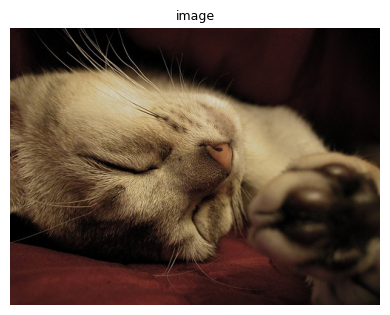

In [22]:
# 4.1. Sanity-check и примеры
seg_indices = np.arange(len(pet_test))
if FAST_MODE:
    seg_indices = take_limited(seg_indices, MAX_SEG_SAMPLES, seed=SEED)

x_img, x_mask = pet_test[int(seg_indices[0])]
print(type(x_img), type(x_mask))
print("mask unique values:", np.unique(np.array(x_mask)))

preview_imgs = [x_img]
preview_masks = [Image.fromarray((pet_gt_to_binary(x_mask).numpy() * 255).astype(np.uint8))]
preview_titles = ["image"]
fig, _ = show_image_grid(preview_imgs, preview_titles, ncols=1, figsize=(4, 4))
plt.show()

In [23]:
# 4.2. Оценка V1 и V2

def evaluate_segmentation(indices: np.ndarray, threshold: float, min_size: int) -> Tuple[pd.DataFrame, Dict[str, float]]:
    rows = []
    for idx in indices:
        img_pil, gt_mask_pil = pet_test[int(idx)]
        gt_bin = pet_gt_to_binary(gt_mask_pil)

        pred_v1, fg_prob, out_hw = predict_pet_foreground(img_pil, threshold=threshold)
        gt_rs = resize_mask_to(gt_bin, out_hw)

        if min_size > 0:
            pred = postprocess_v2(pred_v1, min_size=min_size)
        else:
            pred = pred_v1

        m = binary_metrics(pred, gt_rs)
        rows.append({
            "idx": int(idx),
            "mean_iou": m["mean_iou"],
            "precision": m["precision"],
            "recall": m["recall"],
        })
    df = pd.DataFrame(rows)
    return df, {
        "mean_iou": df["mean_iou"].mean(),
        "precision": df["precision"].mean(),
        "recall": df["recall"].mean(),
    }

v1_df, v1_metrics = evaluate_segmentation(seg_indices, threshold=0.50, min_size=0)
v2_df, v2_metrics = evaluate_segmentation(seg_indices, threshold=0.65, min_size=250)

v1_metrics, v2_metrics

({'mean_iou': np.float64(0.7716869690761938),
  'precision': np.float64(0.7753389162687503),
  'recall': np.float64(0.9949467180098089)},
 {'mean_iou': np.float64(0.7864560146728763),
  'precision': np.float64(0.7929521434376323),
  'recall': np.float64(0.9912617554469417)})

In [24]:
# 4.3. Визуализация нескольких примеров

n_vis = min(4, len(seg_indices))
fig, axes = plt.subplots(n_vis, 4, figsize=(14, 3.5 * n_vis))
if n_vis == 1:
    axes = np.expand_dims(axes, axis=0)

for row in range(n_vis):
    idx = int(seg_indices[row])
    img_pil, gt_mask_pil = pet_test[idx]
    gt_bin = pet_gt_to_binary(gt_mask_pil)

    pred_v1, fg_prob, out_hw = predict_pet_foreground(img_pil, threshold=0.50)
    gt_rs = resize_mask_to(gt_bin, out_hw)
    pred_v2 = postprocess_v2(pred_v1, min_size=250)

    m1 = binary_metrics(pred_v1, gt_rs)
    m2 = binary_metrics(pred_v2, gt_rs)

    axes[row, 0].imshow(img_pil)
    axes[row, 0].set_title("image")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(gt_rs.numpy(), cmap="gray")
    axes[row, 1].set_title("GT foreground")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(pred_v1.numpy(), cmap="gray")
    axes[row, 2].set_title(f"V1 IoU={m1['mean_iou']:.3f}")
    axes[row, 2].axis("off")

    axes[row, 3].imshow(pred_v2.numpy(), cmap="gray")
    axes[row, 3].set_title(f"V2 IoU={m2['mean_iou']:.3f}")
    axes[row, 3].axis("off")

plt.tight_layout()
save_figure(FIG_DIR / "segmentation_examples.png")
print("saved:", FIG_DIR / "segmentation_examples.png")

saved: homeworks/HW10-11/artifacts/figures/segmentation_examples.png


In [25]:
# 4.4. График метрик V1/V2

seg_metrics_df = pd.DataFrame([
    {"experiment_id": "V1", "task": "segmentation", "dataset": "OxfordIIITPet", "seed": SEED,
     "model_summary": "DeepLabV3-ResNet50 / threshold=0.50", "optimizer": "", "lr": np.nan,
     "epochs_trained": 0, "best_val_accuracy": np.nan, "test_accuracy": np.nan,
     "precision": v1_metrics["precision"], "recall": v1_metrics["recall"], "mean_iou": v1_metrics["mean_iou"],
     "notes": "foreground = cat/dog probabilities; no morphology"},
    {"experiment_id": "V2", "task": "segmentation", "dataset": "OxfordIIITPet", "seed": SEED,
     "model_summary": "DeepLabV3-ResNet50 / threshold=0.65 + clean-up", "optimizer": "", "lr": np.nan,
     "epochs_trained": 0, "best_val_accuracy": np.nan, "test_accuracy": np.nan,
     "precision": v2_metrics["precision"], "recall": v2_metrics["recall"], "mean_iou": v2_metrics["mean_iou"],
     "notes": "threshold + opening + remove_small_objects"},
])

plt.figure(figsize=(8, 4))
x = np.arange(2)
w = 0.25
plt.bar(x - w, seg_metrics_df["mean_iou"], width=w, label="mean IoU")
plt.bar(x, seg_metrics_df["precision"], width=w, label="precision")
plt.bar(x + w, seg_metrics_df["recall"], width=w, label="recall")
plt.xticks(x, seg_metrics_df["experiment_id"])
plt.ylim(0, 1)
plt.title("Segmentation metrics: V1 vs V2")
plt.grid(axis="y", alpha=0.3)
plt.legend()
save_figure(FIG_DIR / "segmentation_metrics.png")
print("saved:", FIG_DIR / "segmentation_metrics.png")

saved: homeworks/HW10-11/artifacts/figures/segmentation_metrics.png


In [26]:
# 4.5. Объединяем результаты всех экспериментов и обновляем runs.csv

all_runs = pd.concat([class_results_df, seg_metrics_df], ignore_index=True, sort=False)
all_runs = all_runs[[
    "experiment_id", "task", "dataset", "seed", "model_summary", "optimizer", "lr",
    "epochs_trained", "best_val_accuracy", "test_accuracy", "precision", "recall",
    "mean_iou", "notes"
]]
all_runs.to_csv(ART_DIR / "runs.csv", index=False)
all_runs

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,42,simple cnn / base,Adam,0.0010,5,0.403333,NaN,NaN,NaN,NaN,best_epoch=3; finetune=none; aug=False
1,C2,classification,STL10,42,simple cnn / augmented,Adam,0.0010,5,0.440000,NaN,NaN,NaN,NaN,best_epoch=4; finetune=none; aug=True
2,C3,classification,STL10,42,resnet18 / head-only,Adam,0.0010,3,0.925000,0.92625,NaN,NaN,NaN,best_epoch=3; finetune=head_only; aug=False
3,C4,classification,STL10,42,resnet18 / layer4+fc fine-tune,Adam,0.0001,3,0.908333,NaN,NaN,NaN,NaN,best_epoch=3; finetune=layer4_fc; aug=False
4,V1,segmentation,OxfordIIITPet,42,DeepLabV3-ResNet50 / threshold=0.50,,NaN,0,NaN,NaN,0.775339,0.994947,0.771687,foreground = cat/dog probabilities; no morphology
5,V2,segmentation,OxfordIIITPet,42,DeepLabV3-ResNet50 / threshold=0.65 + clean-up,,NaN,0,NaN,NaN,0.792952,0.991262,0.786456,threshold + opening + remove_small_objects


## 5. Артефакты

После полного запуска ноутбука в `artifacts/` будут лежать:

- `runs.csv`
- `best_classifier.pt`
- `best_classifier_config.json`
- `figures/classification_curves_best.png`
- `figures/classification_compare.png`
- `figures/augmentations_preview.png`
- `figures/segmentation_examples.png`
- `figures/segmentation_metrics.png`